C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading txs_features...
  shape: (203769, 184)
  columns: ['txId', 'Time step', 'Local_feature_1', 'Local_feature_2', 'Local_feature_3', 'Local_feature_4', 'Local_feature_5', 'Local_feature_6', 'Local_feature_7', 'Local_feature_8'] ...

Loading txs_classes...
  shape: (203769, 2)
  columns: ['txId', 'class']
  class unique: [3 2 1]

Loading txs_edgelist...
  shape: (234355, 2)
  columns: ['txId1', 'txId2']

=== Features overview ===
    txId  Time step  Local_feature_1  Local_feature_2  Local_feature_3  \
0   3321          1        -0.169615        -0.184668        -1.201369   
1  11108          1        -0.137586        -0.184668        -1.201369   
2  51816          1        -0.170103        -0.184668        -1.201369   
3  68869          1        -0.114267        -0.184668        -1.201369   
4  89273          1         5.202107        -0.210553        -1.756361   

   Local_feature_4  Local_feature_5  Local_feature_6  Local_feature_7  \
0        -0.121970        -0.043875        -0

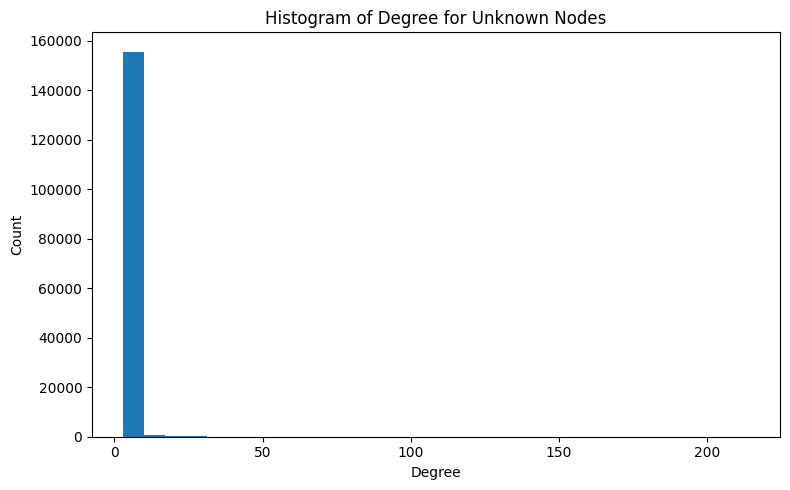

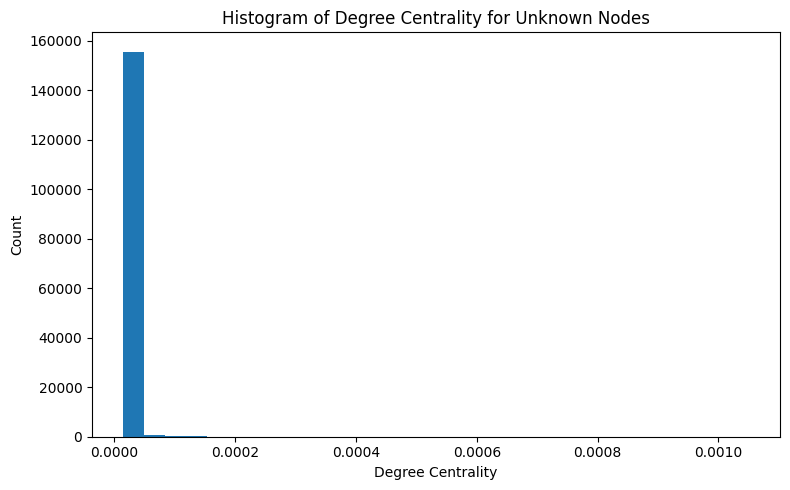


=== time step ごとの unknown ノード集計 ===
 time_step  unknown_count  avg_degree  avg_degree_centrality  max_degree  max_degree_centrality
         1           5733    4.180359               0.000021         136               0.000667
         2           3427    4.144733               0.000020          42               0.000206
         3           5342    4.526956               0.000022          31               0.000152
         4           4253    4.703503               0.000023          44               0.000216
         5           4921    4.514326               0.000022         214               0.001050
         6           3843    4.369503               0.000021         158               0.000775
         7           4845    4.197110               0.000021          48               0.000236
         8           3292    4.099332               0.000020          38               0.000186
         9           4218    4.339023               0.000021          93               0.000456
   

In [1]:
"""
Elliptic++ 風トランザクショングラフに対して、
unknown ノード（class=3 -> y=-1）の数を数え、
すべての unknown ノードの次数・次数中心性を計算する完全版。

やること
1) txs_features / txs_classes / txs_edgelist を読み込む
2) class=3 を unknown として y=-1 に変換
3) PyG Data を構築
4) unknown ノード数を数える
5) すべての unknown ノードの次数・次数中心性を計算
6) 上位表示
7) ヒストグラム表示
"""

import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, add_self_loops, to_networkx

warnings.filterwarnings("ignore")


# ==========================
# 設定
# ==========================
TXS_FEATURES = "./transactions/txs_features.txt"
TXS_CLASSES  = "./transactions/txs_classes.txt"
TXS_EDGES    = "./transactions/txs_edgelist.txt"

SEED = 42

# 表示設定
TOP_K = 20
FIGSIZE_HIST = (8, 5)
BINS = 30

# Time step を特徴量に入れるか
INCLUDE_TIME_STEP_AS_FEATURE = False


# ==========================
# 乱数固定
# ==========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# ==========================
# ファイル確認
# ==========================
def check_files():
    for path in [TXS_FEATURES, TXS_CLASSES, TXS_EDGES]:
        if not Path(path).exists():
            raise FileNotFoundError(f"ファイルが見つかりません: {path}")


# ==========================
# データ読み込み
# ==========================
def load_raw_data():
    print("Loading txs_features...")
    df_features = pd.read_csv(TXS_FEATURES)
    print("  shape:", df_features.shape)
    print("  columns:", list(df_features.columns[:10]), "...")

    print("\nLoading txs_classes...")
    df_classes = pd.read_csv(TXS_CLASSES)
    print("  shape:", df_classes.shape)
    print("  columns:", list(df_classes.columns))
    if "class" in df_classes.columns:
        print("  class unique:", df_classes["class"].unique())

    print("\nLoading txs_edgelist...")
    df_edges = pd.read_csv(TXS_EDGES)
    print("  shape:", df_edges.shape)
    print("  columns:", list(df_edges.columns))

    print("\n=== Features overview ===")
    print(df_features.head())
    print("missing values (total):", int(df_features.isnull().sum().sum()))

    print("\n=== Classes overview ===")
    if "class" in df_classes.columns:
        print(df_classes["class"].value_counts(dropna=False))

    print("\n=== Edges overview ===")
    print(df_edges.head())
    print("duplicate edges:", int(df_edges.duplicated().sum()))

    return df_features, df_classes, df_edges


# ==========================
# class の正規化
# ==========================
def normalize_class_value(v):
    """
    Elliptic 系の class 値を統一して扱う
      1 / '1' / 'illicit' -> 0
      2 / '2' / 'licit'   -> 1
      3 / '3' / 'unknown' -> -1
    """
    if pd.isna(v):
        return -1

    s = str(v).strip().lower()

    if s in {"1", "illicit"}:
        return 0
    elif s in {"2", "licit"}:
        return 1
    elif s in {"3", "unknown"}:
        return -1
    else:
        return -1


# ==========================
# PyG Data 構築
# ==========================
def build_pyg_data(
    df_features: pd.DataFrame,
    df_classes: pd.DataFrame,
    df_edges: pd.DataFrame,
    include_time_step_as_feature: bool = False
):
    id_col_feat = df_features.columns[0]
    print(f"\n[build_pyg_data] using '{id_col_feat}' as node id column.")

    if "Time step" not in df_features.columns:
        raise ValueError("df_features に 'Time step' 列がありません。")

    # ---- Time step ----
    time_steps_np = pd.to_numeric(
        df_features["Time step"], errors="coerce"
    ).fillna(-1).to_numpy(dtype=np.int64)
    time_steps = torch.tensor(time_steps_np, dtype=torch.long)

    print("[build_pyg_data] time step min/max:",
          int(time_steps.min().item()), int(time_steps.max().item()))

    # ---- 特徴量 ----
    feature_cols = [c for c in df_features.columns if c != id_col_feat]
    if not include_time_step_as_feature:
        feature_cols = [c for c in feature_cols if c != "Time step"]

    x_df = df_features[feature_cols].copy()
    x_df = x_df.apply(pd.to_numeric, errors="coerce")
    x_df = x_df.replace([np.inf, -np.inf], np.nan)
    x_df = x_df.fillna(0.0)

    x_np = x_df.to_numpy(dtype=np.float32)
    x = torch.tensor(x_np, dtype=torch.float)

    print("[build_pyg_data] x shape:", tuple(x.shape))
    print("[build_pyg_data] torch.isnan(x).any():", torch.isnan(x).any().item())
    print("[build_pyg_data] torch.isinf(x).any():", torch.isinf(x).any().item())

    # ---- ラベル ----
    if "class" not in df_classes.columns:
        raise ValueError("df_classes に 'class' 列がありません。")

    if id_col_feat in df_classes.columns:
        id_col_cls = id_col_feat
    else:
        id_col_cls = df_classes.columns[0]
        print(f"[build_pyg_data] WARNING: using '{id_col_cls}' as class id column.")

    node_ids = df_features[id_col_feat].astype(int).values
    id2idx = {int(nid): i for i, nid in enumerate(node_ids)}

    cls_series = (
        df_classes
        .set_index(id_col_cls)["class"]
        .reindex(node_ids)
    )

    y_np = cls_series.map(normalize_class_value).to_numpy(dtype=np.int64)
    y = torch.tensor(y_np, dtype=torch.long)

    print("[build_pyg_data] y value counts:")
    print(pd.Series(y_np).value_counts(dropna=False).sort_index())

    # ---- エッジ ----
    edge_cols = list(df_edges.columns[:2])
    src_raw = df_edges[edge_cols[0]].values
    dst_raw = df_edges[edge_cols[1]].values

    src_idx = []
    dst_idx = []
    missing_edges = 0

    for u, v in zip(src_raw, dst_raw):
        u = int(u)
        v = int(v)
        if u in id2idx and v in id2idx:
            src_idx.append(id2idx[u])
            dst_idx.append(id2idx[v])
        else:
            missing_edges += 1

    edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)
    edge_index = to_undirected(edge_index, num_nodes=len(node_ids))
    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

    print("[build_pyg_data] edge_index shape:", tuple(edge_index.shape))
    print("[build_pyg_data] skipped edges with unknown nodes:", missing_edges)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.time_steps = time_steps
    data.node_ids = torch.tensor(node_ids, dtype=torch.long)

    return data


# ==========================
# unknown ノード数 + 次数中心性
# ==========================
def count_unknown_and_degree_centrality(data: Data):
    """
    unknown ノード（y=-1）の
    - 個数
    - 次数
    - 次数中心性
    を計算して DataFrame で返す
    """
    G = to_networkx(data.cpu(), to_undirected=True)

    y = data.y.cpu().numpy()
    node_ids = data.node_ids.cpu().numpy()
    time_steps = data.time_steps.cpu().numpy()

    unknown_nodes = np.where(y == -1)[0]
    n_unknown = len(unknown_nodes)

    print("\n=== unknown ノード数 ===")
    print(f"unknown ノード数: {n_unknown}")

    deg_cent = nx.degree_centrality(G)

    rows = []
    for n in unknown_nodes:
        rows.append({
            "node_index": int(n),
            "txId": int(node_ids[n]),
            "time_step": int(time_steps[n]),
            "degree": int(G.degree[n]),
            "degree_centrality": float(deg_cent[n]),
        })

    df_unknown = pd.DataFrame(rows)

    if len(df_unknown) == 0:
        print("unknown ノードは存在しません。")
        return n_unknown, df_unknown, G

    df_unknown = df_unknown.sort_values(
        ["degree_centrality", "degree", "node_index"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    print(f"\n=== unknown ノードの次数中心性 上位 {min(TOP_K, len(df_unknown))} 件 ===")
    print(df_unknown.head(TOP_K).to_string(index=False))

    print("\n=== unknown ノードの基本統計 ===")
    print(df_unknown[["degree", "degree_centrality"]].describe())

    return n_unknown, df_unknown, G


# ==========================
# ヒストグラム表示
# ==========================
def plot_unknown_degree_histograms(df_unknown: pd.DataFrame):
    if len(df_unknown) == 0:
        print("[hist] unknown ノードがないため描画をスキップします。")
        return

    # 次数ヒストグラム
    plt.figure(figsize=FIGSIZE_HIST)
    plt.hist(df_unknown["degree"], bins=BINS)
    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.title("Histogram of Degree for Unknown Nodes")
    plt.tight_layout()
    plt.show()

    # 次数中心性ヒストグラム
    plt.figure(figsize=FIGSIZE_HIST)
    plt.hist(df_unknown["degree_centrality"], bins=BINS)
    plt.xlabel("Degree Centrality")
    plt.ylabel("Count")
    plt.title("Histogram of Degree Centrality for Unknown Nodes")
    plt.tight_layout()
    plt.show()


# ==========================
# time step ごとの unknown 数
# ==========================
def summarize_unknown_by_time_step(df_unknown: pd.DataFrame):
    if len(df_unknown) == 0:
        print("[time step summary] unknown ノードがありません。")
        return

    summary = (
        df_unknown.groupby("time_step")
        .agg(
            unknown_count=("node_index", "count"),
            avg_degree=("degree", "mean"),
            avg_degree_centrality=("degree_centrality", "mean"),
            max_degree=("degree", "max"),
            max_degree_centrality=("degree_centrality", "max"),
        )
        .reset_index()
        .sort_values("time_step")
    )

    print("\n=== time step ごとの unknown ノード集計 ===")
    print(summary.to_string(index=False))


# ==========================
# main
# ==========================
def main():
    set_seed(SEED)
    check_files()

    # 1) データ読み込み
    df_features, df_classes, df_edges = load_raw_data()

    # 2) PyG Data 構築
    data = build_pyg_data(
        df_features=df_features,
        df_classes=df_classes,
        df_edges=df_edges,
        include_time_step_as_feature=INCLUDE_TIME_STEP_AS_FEATURE
    )

    # 3) unknown ノード数と次数中心性
    n_unknown, df_unknown, G = count_unknown_and_degree_centrality(data)

    # 4) ヒストグラム
    plot_unknown_degree_histograms(df_unknown)

    # 5) time step ごとの集計
    summarize_unknown_by_time_step(df_unknown)

    print("\nDone.")


if __name__ == "__main__":
    main()